# Preprocessing

## Prepare

In [190]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

In [191]:
train = pd.read_csv('../../data/raw/train.csv')
test = pd.read_csv('../../data/raw/test.csv')

## Remove duplicate

In [192]:
train[train.duplicated(subset = train.columns.difference(['class']))]

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class


In [193]:
test[test.duplicated(subset = test.columns.difference(['class']))]

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature


In [194]:
train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

## Fill missing value.

**There are three feature have missing value.**
+ Popularity
+ key
+ instrumentalness

Cột Popularity và instrumentalness có các giá trị ngoại lai nên ta có thể điền median, vì median không ảnh hưởng bởi các giá trị ngoại lai.

In [195]:
imp = SimpleImputer (missing_values = np.nan , strategy = 'median')
train[['Popularity', 'instrumentalness']] = imp.fit_transform(train[['Popularity', 'instrumentalness']])
test[['Popularity', 'instrumentalness']] = imp.transform(test[['Popularity', 'instrumentalness']])

Với key nếu điền cái giá trị như median và mean thì có thể làm sai dữ liệu. Đồng thời key cũng là 1 biến phân loại nên ta sẽ điền -1 cho các giá trị còn thiếu.

In [196]:
imp = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value = -1)
train[['key']] = imp.fit_transform(train[['key']])
test[['key']] = imp.transform(test[['key']])

In [197]:
train.isnull().sum()
test.isnull().sum()

Id                    0
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
dtype: int64

## Handle data skewness

In [198]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_skewness(df):
    # 1. Lọc ra các cột số (loại bỏ cột tên bài hát, tên nghệ sĩ...)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Loại bỏ cột 'key' và 'mode' vì chúng là biến phân loại (categorical)
    cols_to_exclude = ['key', 'mode', 'time_signature']
    numeric_cols = [c for c in numeric_cols if c not in cols_to_exclude]

    # 2. Tính toán chỉ số Skewness
    skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
    
    print("--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---")
    print(skew_vals)
    print("\n" + "="*40 + "\n")

    # 3. Vẽ biểu đồ trực quan
    # Tính toán số hàng cần thiết cho lưới biểu đồ
    n_cols_plot = 3  
    n_rows_plot = (len(numeric_cols) + n_cols_plot - 1) // n_cols_plot

    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
    axes = axes.flatten() # Làm phẳng mảng axes để dễ lặp

    for i, col in enumerate(numeric_cols):
        # Vẽ Histogram kèm đường cong mật độ (KDE)
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')
        
        # Vẽ đường Trung bình (Mean) và Trung vị (Median) để thấy rõ độ lệch
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean (TB)')
        axes[i].axvline(df[col].median(), color='green', linestyle='-', label='Median (TV)')
        
        # Tiêu đề hiển thị tên cột và giá trị Skew
        axes[i].set_title(f'{col}\nSkew: {round(skew_vals[col], 2)}', fontsize=12, fontweight='bold')
        axes[i].legend()

    # Tắt các ô biểu đồ thừa (nếu có)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---
speechiness           3.113395
liveness              2.178265
instrumentalness      1.972589
acousticness          1.108933
duration_in min/ms    0.836407
tempo                 0.376507
valence               0.088687
Popularity            0.078797
Id                    0.000000
danceability         -0.075651
energy               -0.656698
Class                -0.666563
loudness             -1.748073
dtype: float64




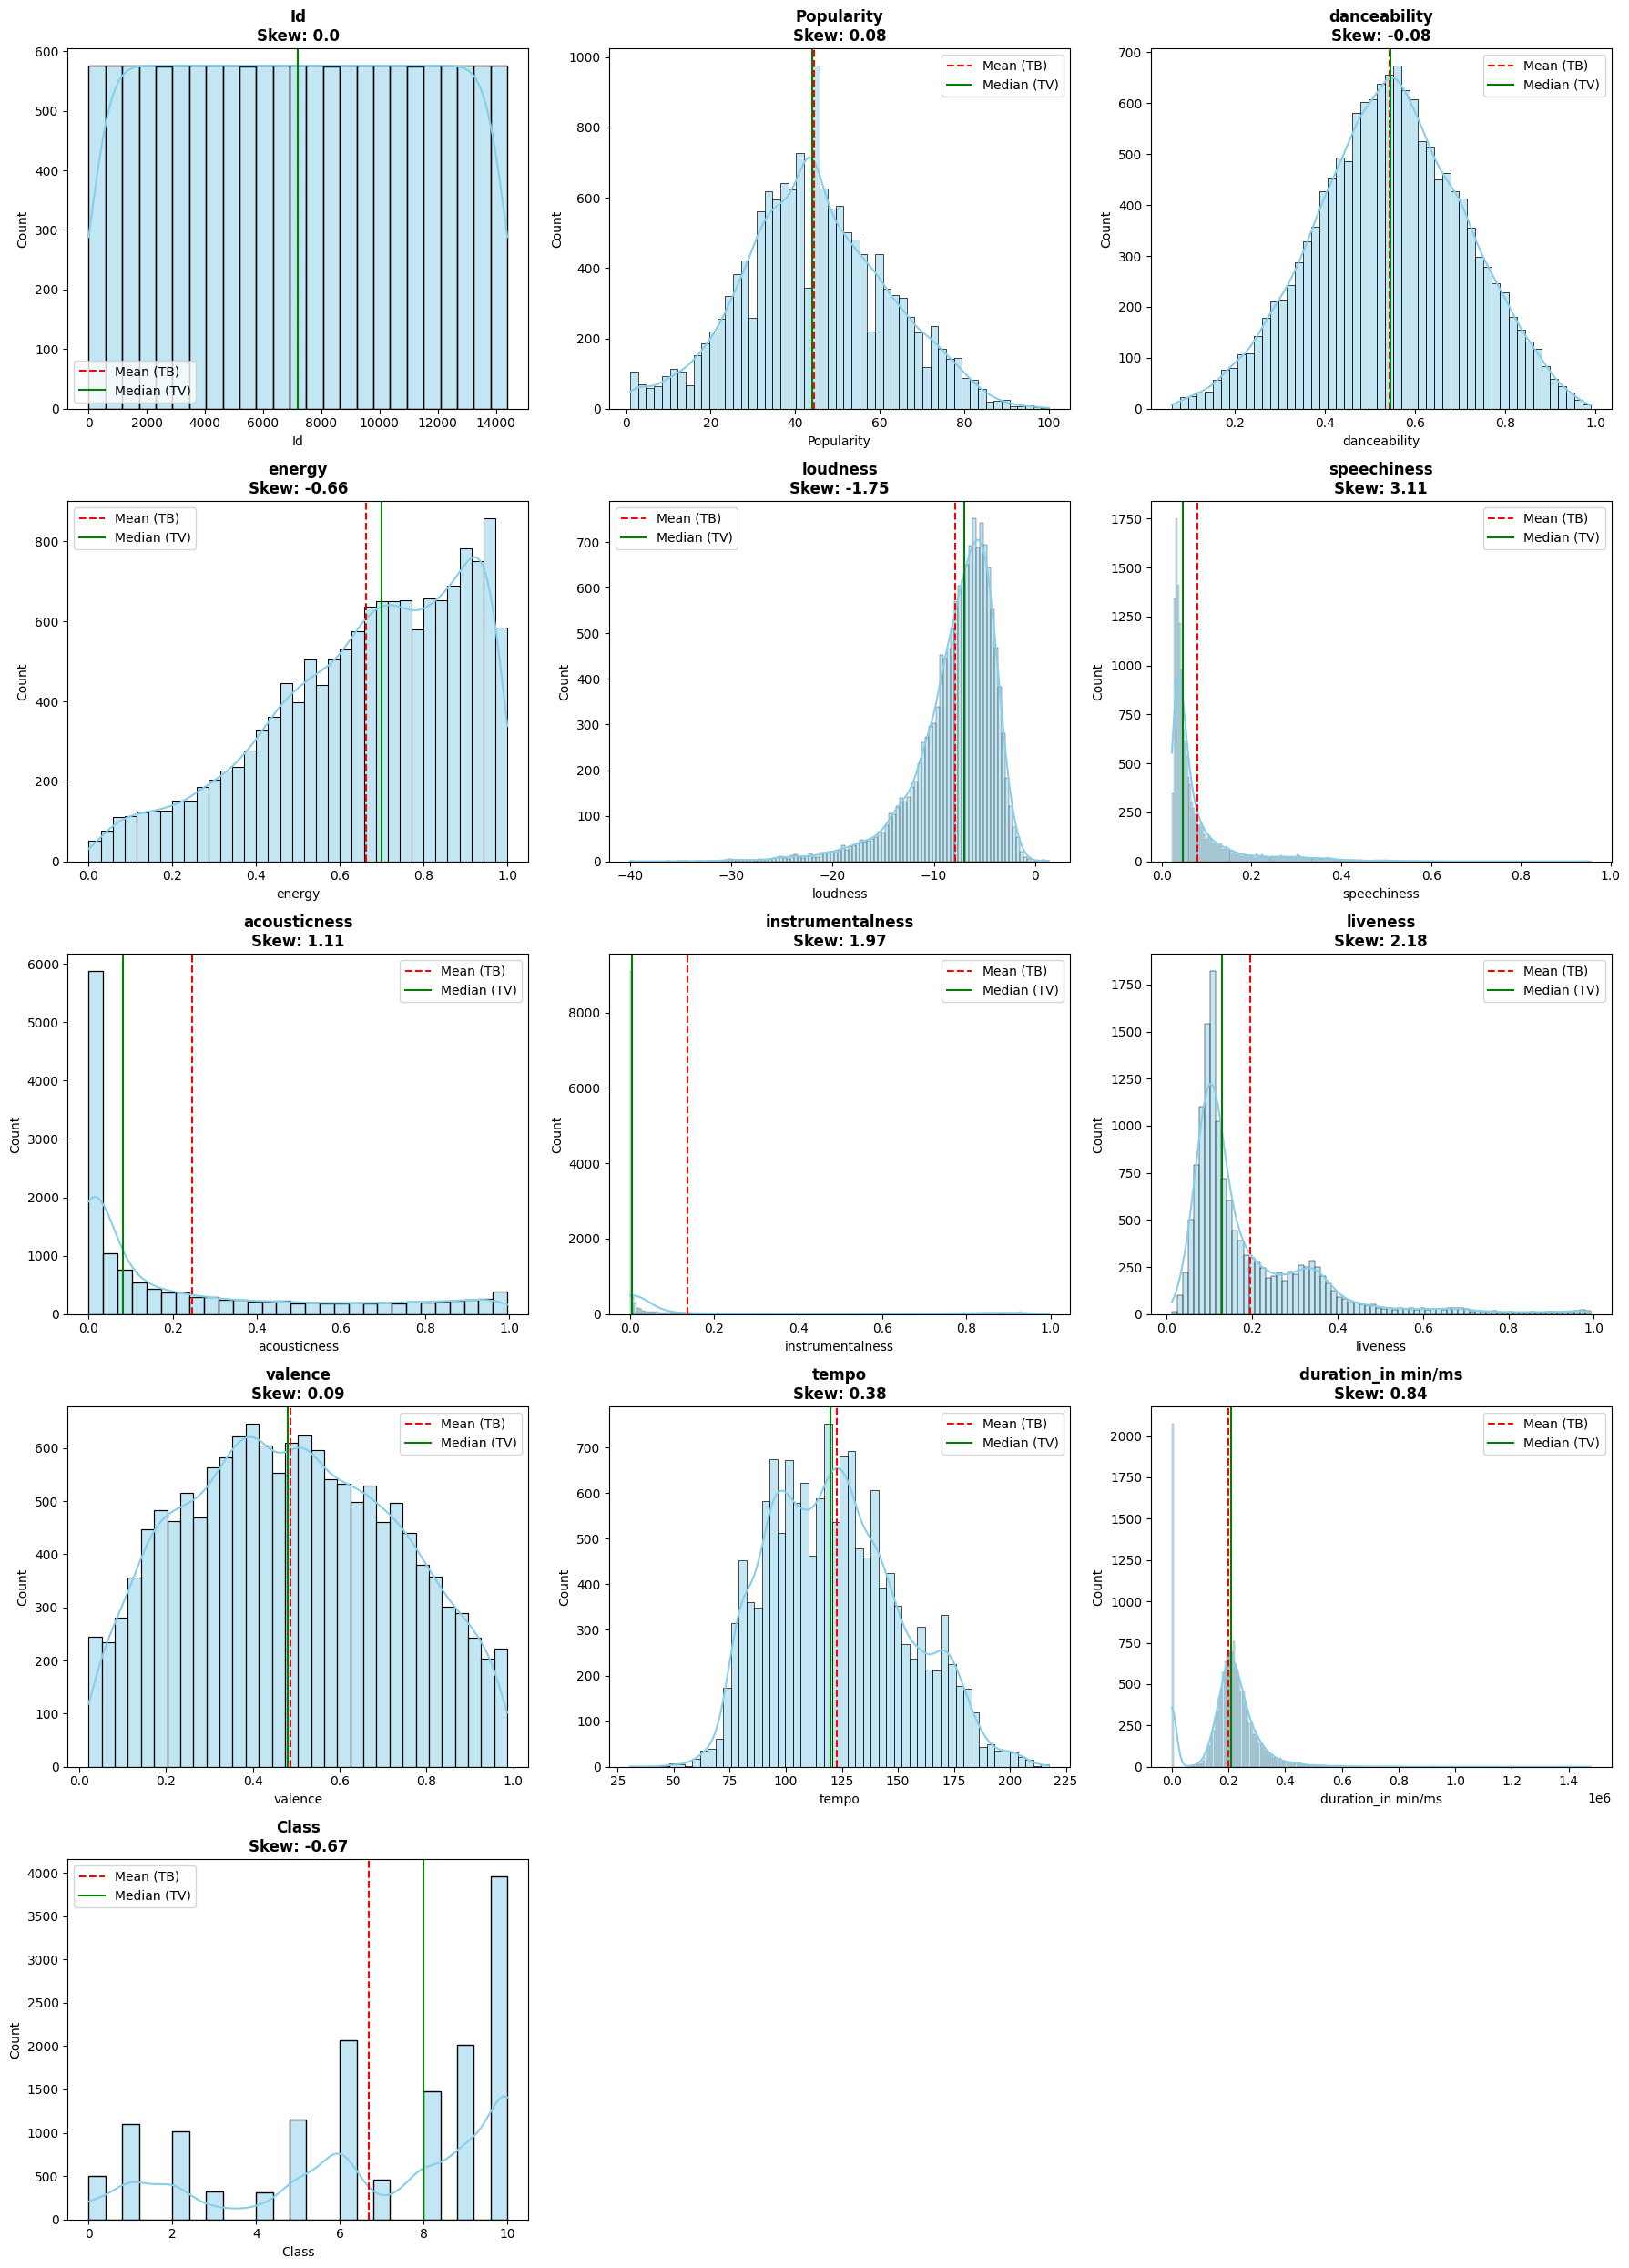

In [199]:
analyze_skewness(train)

In [ ]:
# Sử dụng Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson', standardize=True)
train[['energy', 'loudness', 'liveness', 'tempo']] = pt.fit_transform(train[['energy', 'loudness', 'liveness', 'tempo']])
test[['energy', 'loudness', 'liveness', 'tempo']] = pt.transform(test[['energy', 'loudness', 'liveness', 'tempo']])


In [ ]:
# Using log transformation
train['instrumentalness'] = np.log1p(train['instrumentalness'])
test['instrumentalness'] = np.log1p(test['instrumentalness'])

In [ ]:
# Using square root transformation
train['duration_in min/ms'] = np.sqrt(train['duration_in min/ms'])
test['duration_in min/ms'] = np.sqrt(test['duration_in min/ms'])

In [ ]:
# Using cube root transformation
train['acousticness'] = np.cbrt(train['acousticness'])
test['acousticness'] = np.cbrt(test['acousticness'])

In [ ]:
# Using reciprocal transformation
train['speechiness'] = 1/(train['speechiness'] + 1e-6)
test['speechiness'] = 1/(test['speechiness'] + 1e-6)

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---
instrumentalness      1.848639
liveness              0.324864
acousticness          0.195003
valence               0.088687
Popularity            0.078797
loudness              0.014902
Id                    0.000000
tempo                -0.010150
danceability         -0.075651
speechiness          -0.094009
energy               -0.162370
Class                -0.666563
duration_in min/ms   -1.336633
dtype: float64




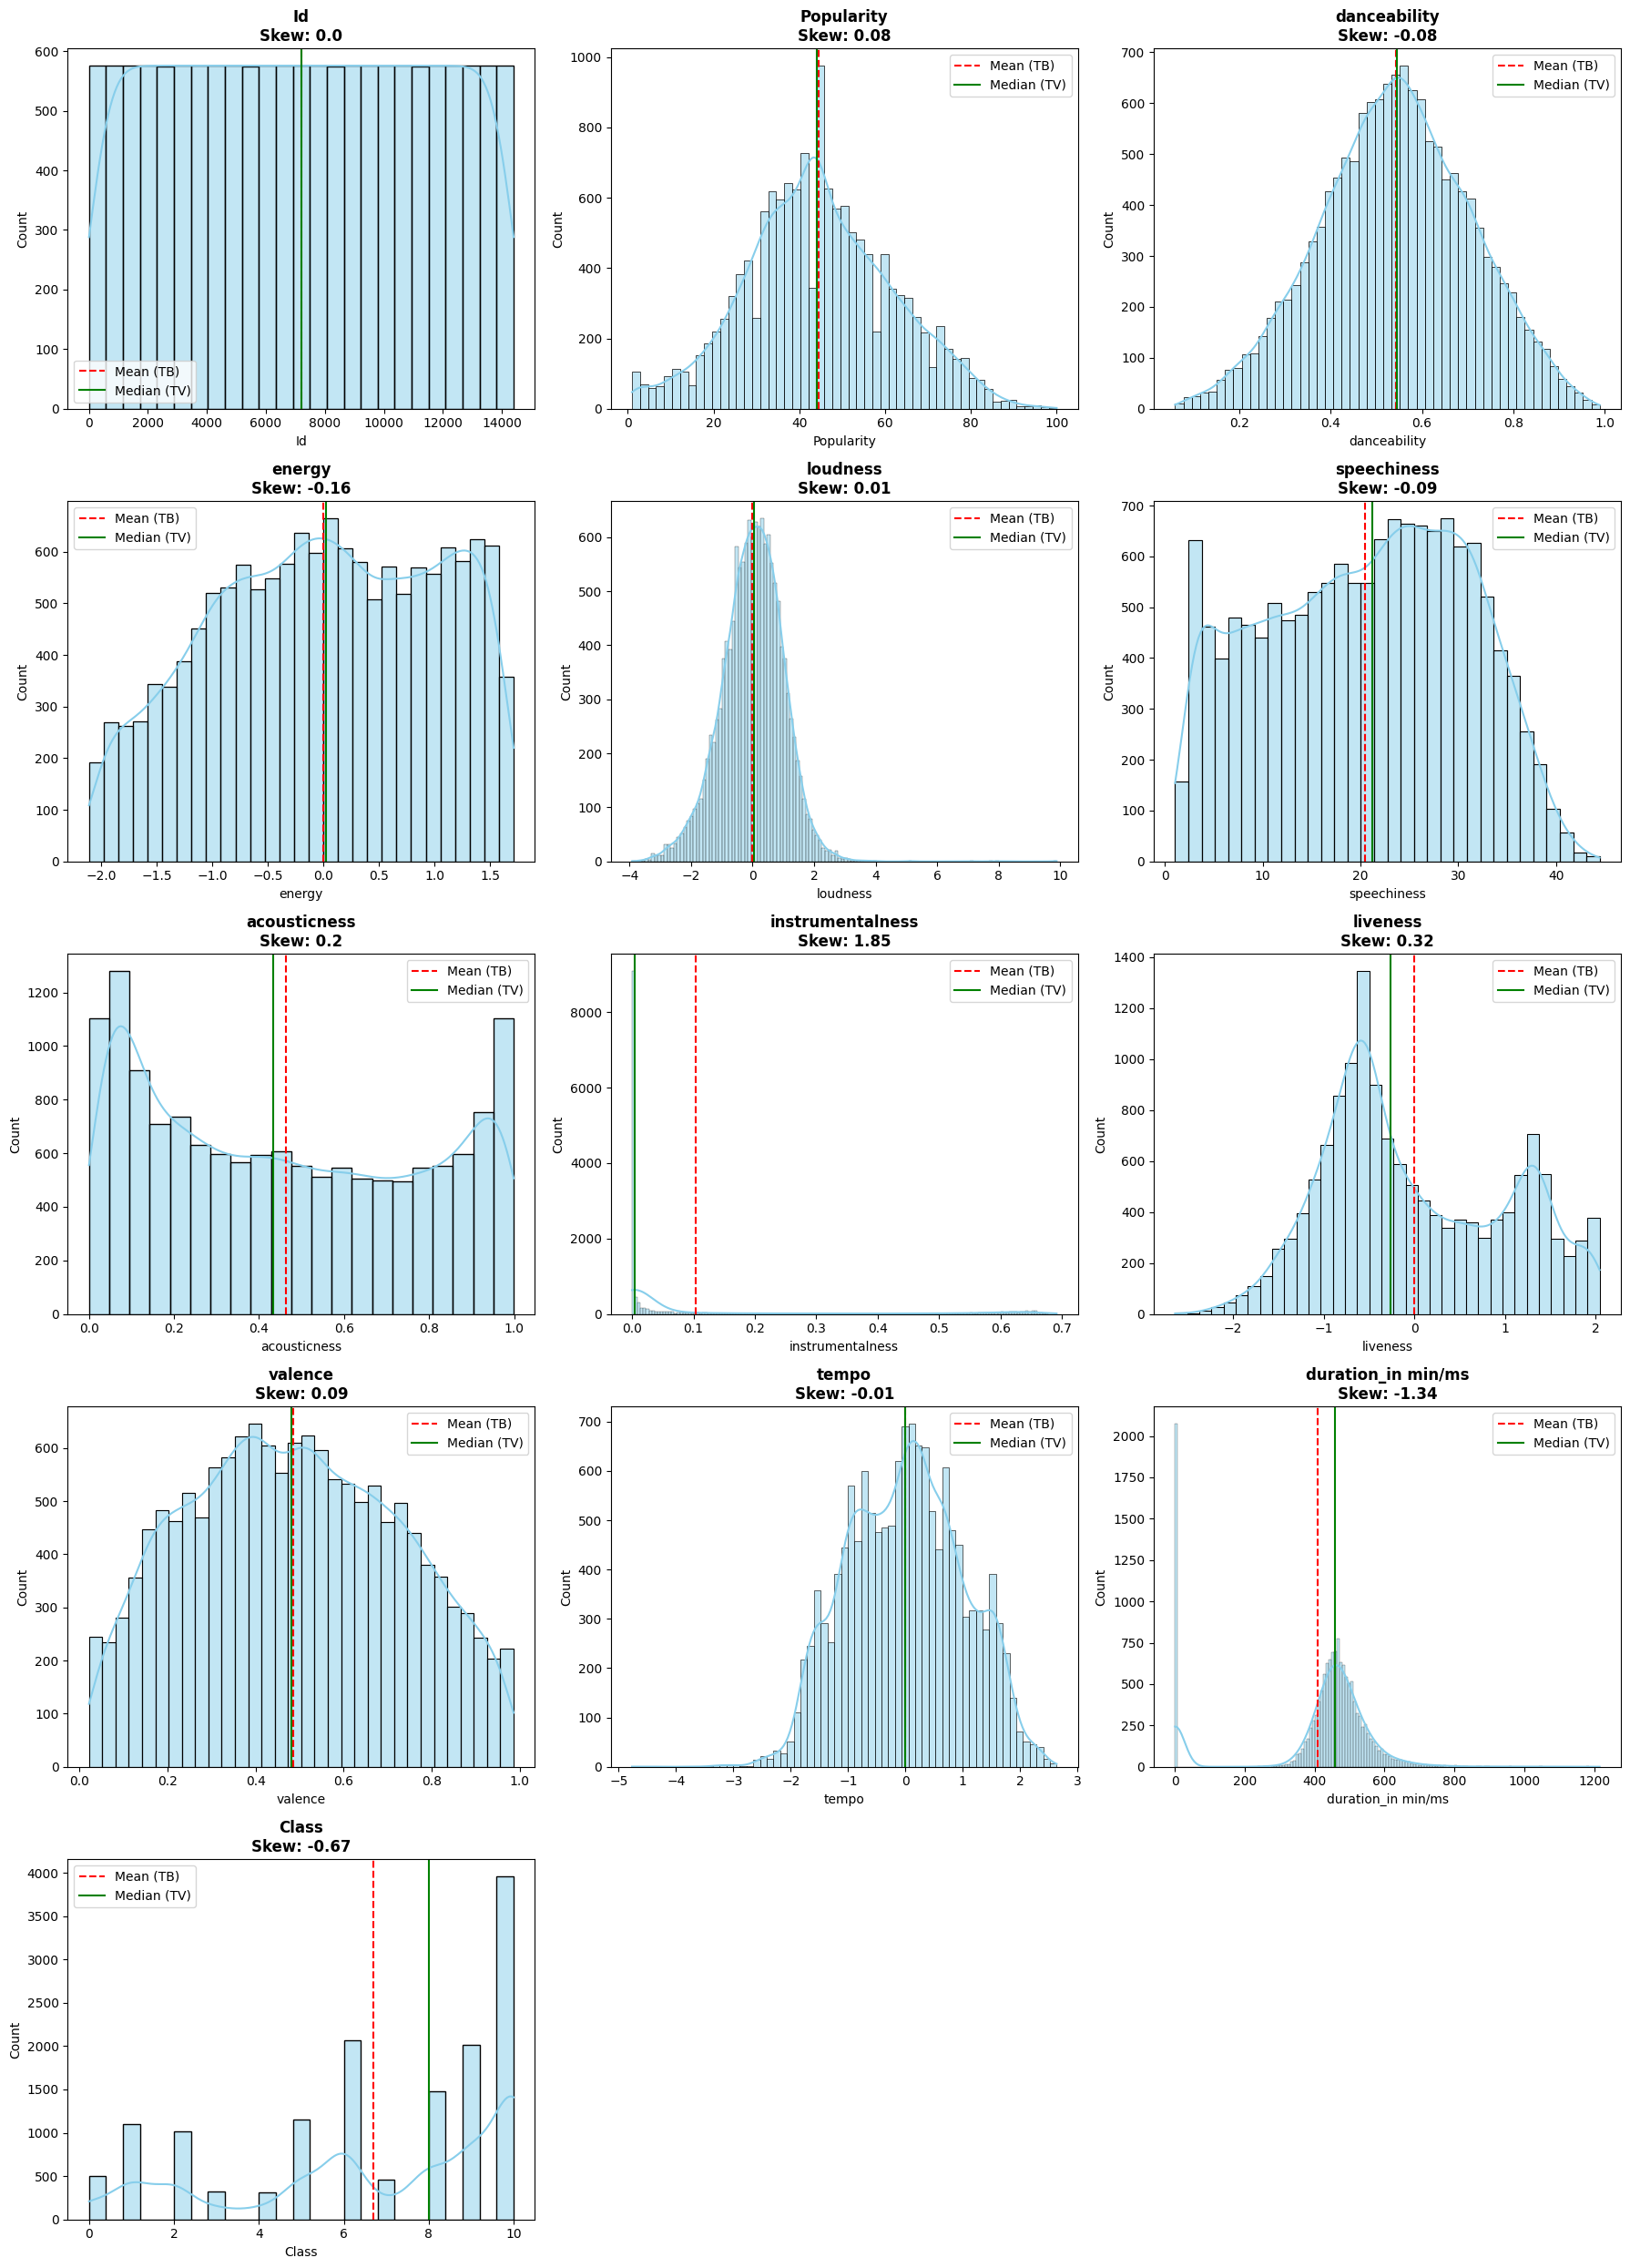

In [205]:
analyze_skewness(train)

--- CHỈ SỐ ĐỘ LỆCH (SKEWNESS) ---
instrumentalness      1.848353
liveness              0.320872
acousticness          0.179880
valence               0.094937
Popularity            0.078566
tempo                 0.014151
Id                    0.000000
speechiness          -0.023516
loudness             -0.032003
danceability         -0.113982
energy               -0.181280
duration_in min/ms   -1.343391
dtype: float64




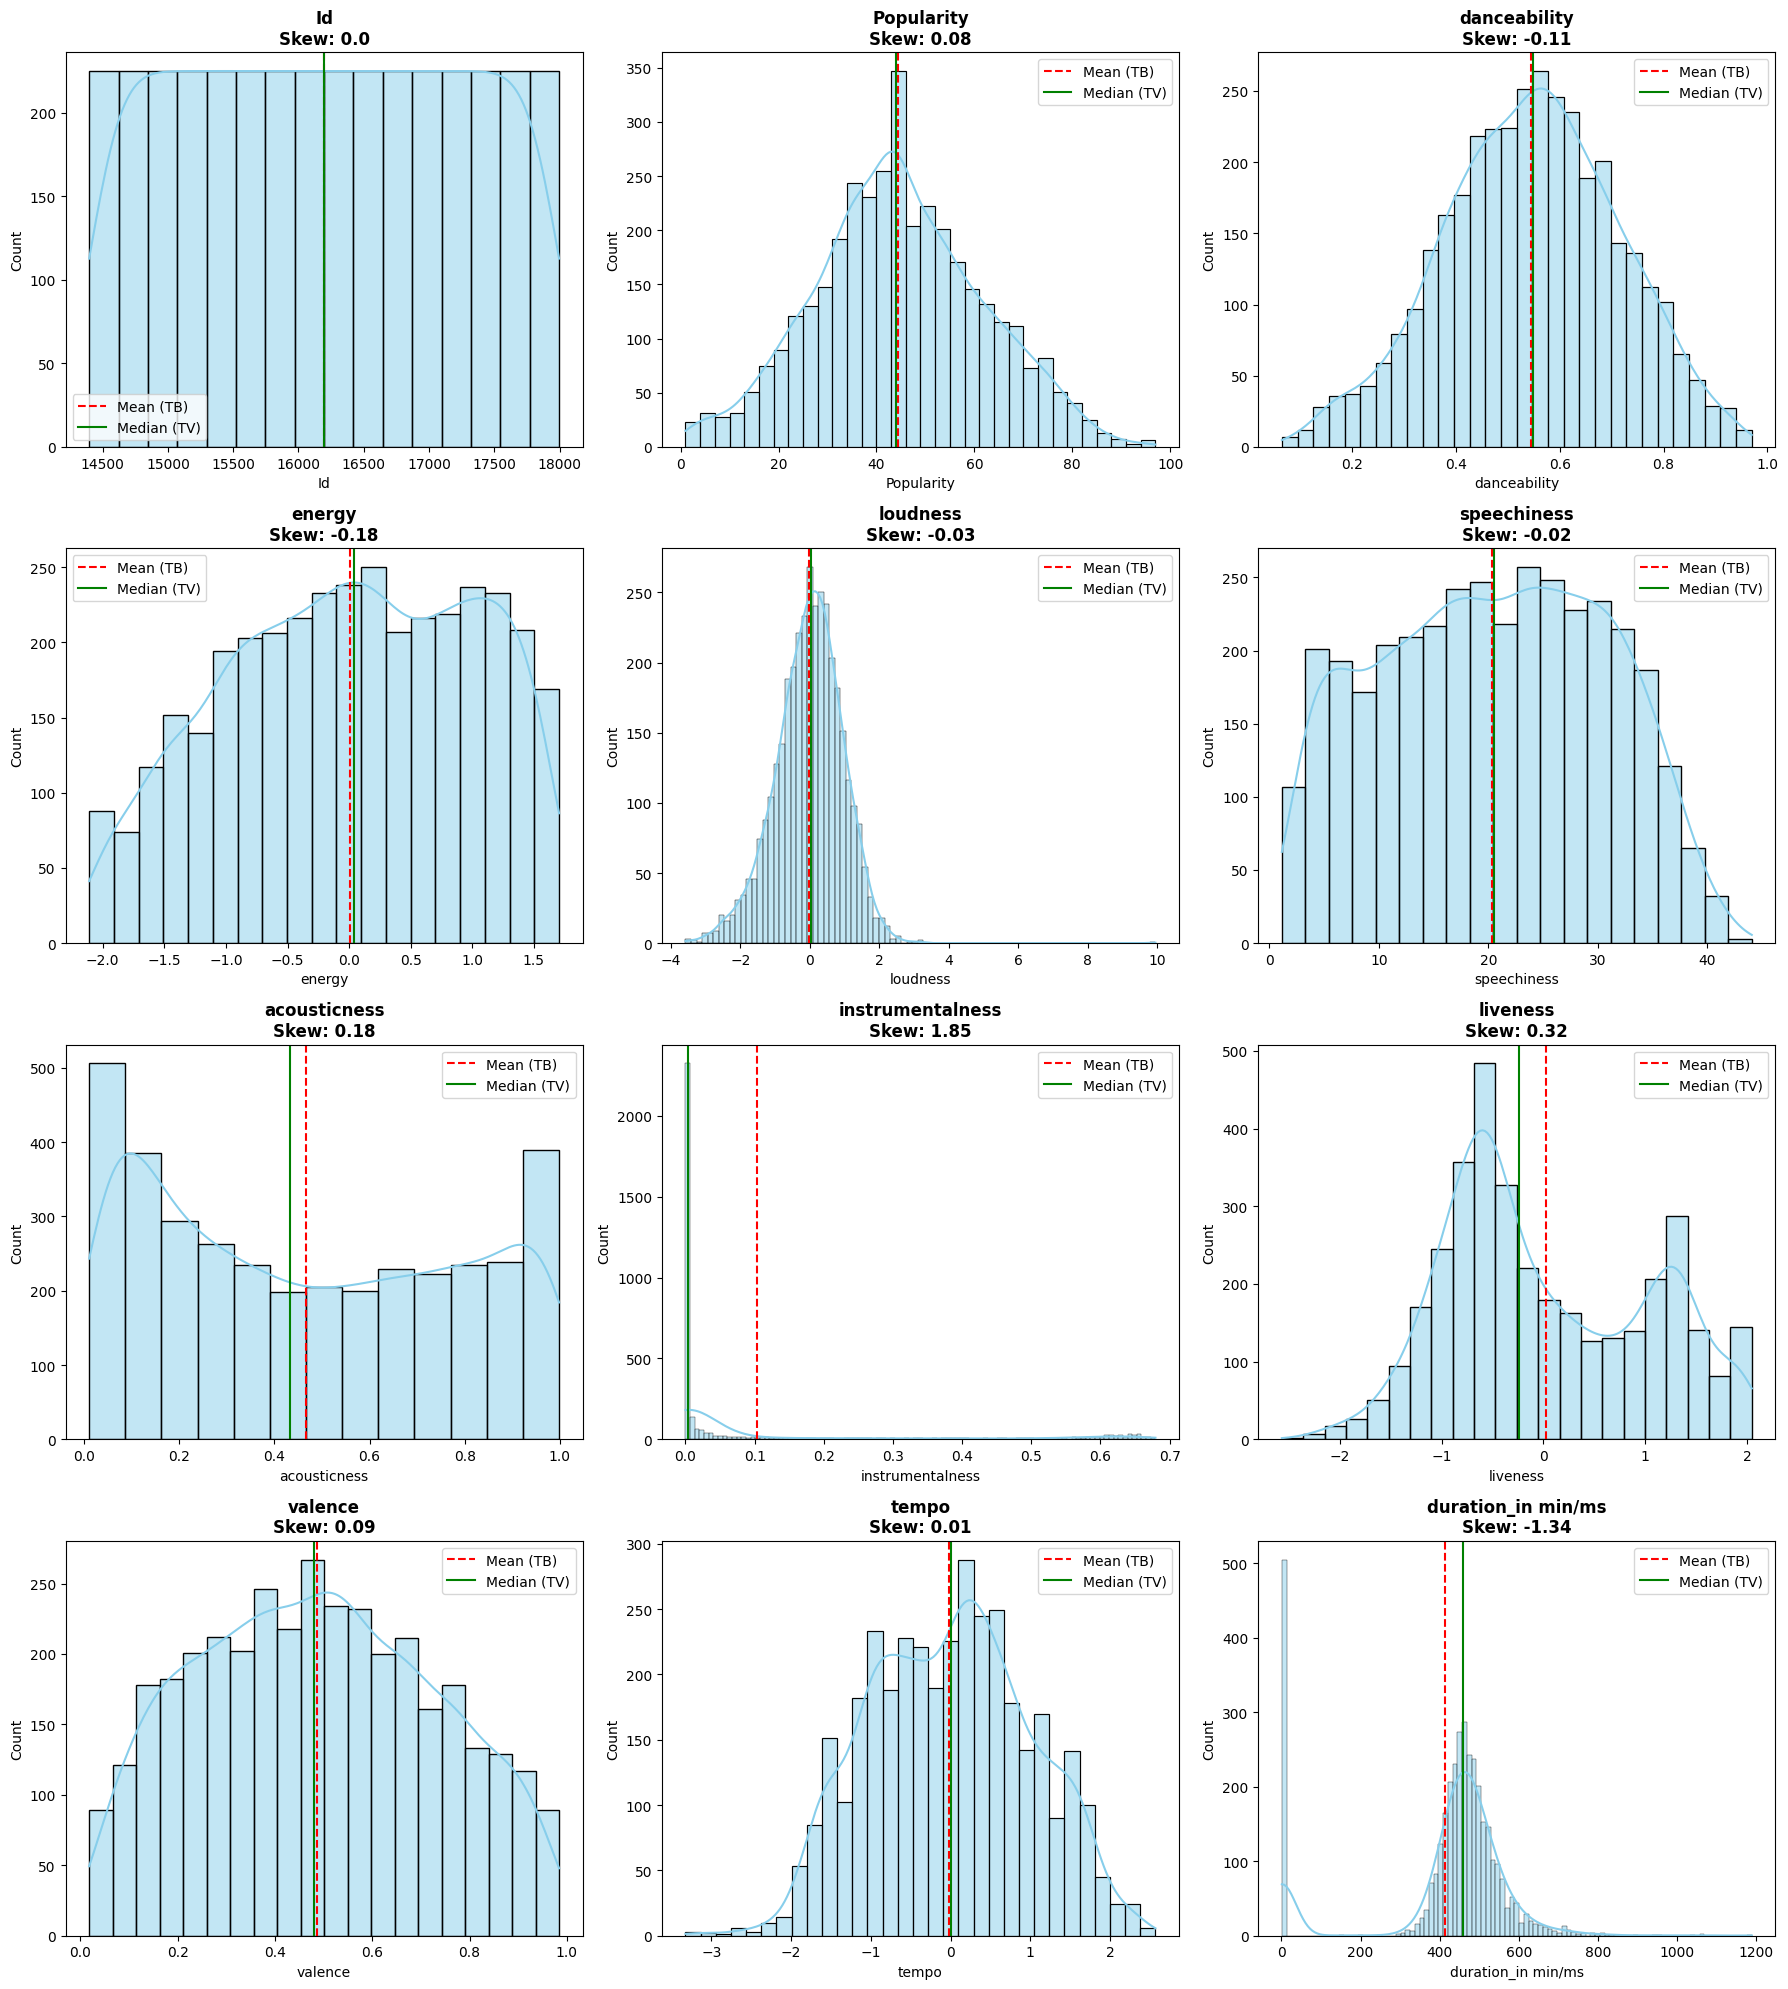

In [206]:
analyze_skewness(test)

## Treat outliers

Thay thế giá trị ngoại lai bằng giới hạn trên hoặc giới hạn dưới được tính toán bằng phương pháp thống kê IQR

In [207]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cap_outliers_iqr(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        # 1. Tính toán IQR
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 2. Xác định giới hạn
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 3. Đếm số lượng outlier trước khi xử lý (để theo dõi)
        outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        
        if outliers_count > 0:
            # 4. Capping (Gán giá trị)
            # Dùng np.where: Nếu > upper thì lấy upper, ngược lại giữ nguyên
            df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])
            
            # Nếu < lower thì lấy lower, ngược lại giữ nguyên
            df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
            
    return df_clean

In [208]:
train = cap_outliers_iqr(train, ['Popularity', 'loudness', 'danceability', 'instrumentalness', 'tempo', 'duration_in min/ms'])
test = cap_outliers_iqr(test, ['Popularity', 'loudness', 'danceability', 'instrumentalness', 'tempo', 'duration_in min/ms'])    

In [209]:
train.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,-0.676218,9.0,0.153284,0,26.246030,0.723043,0.003912,-0.598627,0.235,1.014464,452.710724,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.256062,11.0,0.523145,1,11.415395,0.300739,0.045738,-0.629790,0.380,0.425560,438.127835,4,6
2,3,Royal & the Serpent,phuck u,44.0,0.584,0.550185,7.0,0.332191,1,16.154828,0.098922,0.139563,1.055408,0.635,1.226456,401.294156,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,-1.433464,-1.0,-1.572682,1,32.050255,0.967986,0.021076,1.134827,0.501,1.563116,545.978937,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.408517,6.0,0.691321,0,4.016048,0.567741,0.003912,0.583192,0.619,-1.217968,504.127960,4,5


In [210]:
test.head()

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,14397,Juan Pablo Vega,Matando (feat. Vic Mirallas),44.0,0.691,-0.111961,2.0,0.019057,0,10.626880,0.423024,0.034595,0.466742,0.635,-1.146966,447.213595,4
1,14398,Kappi Kat,Baarish,14.0,0.461,0.408517,2.0,-0.089107,1,32.678671,0.729363,0.129986,1.091041,0.525,1.311347,532.831118,4
2,14399,Plain White T's,Hey There Delilah,80.0,0.656,-1.480544,2.0,-0.835835,1,34.128528,0.955371,0.003912,-0.478012,0.298,-0.581848,482.216756,4
3,14400,WALK THE MOON,Different Colors,52.0,0.480,0.668789,-1.0,0.890930,1,25.188282,0.092716,0.000001,-0.322177,0.687,-0.895911,471.224999,4
4,14401,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.167058,1.0,0.238035,0,3.533556,0.527763,0.003912,-1.284457,0.805,-1.778952,344.149677,4


## Save File

In [213]:
train.to_csv("../../data/preprocessed/preprocessed_train.csv")
test.to_csv("../../data/preprocessed/preprocessed_test.csv")
print("Successfully saved preprocessed data.")

Successfully saved preprocessed data.


# The end